<cell_type>markdown</cell_type># SNN vs ICE on CIFAR-10

Same comparison as `comparison_snn_vs_ice.ipynb` but on **CIFAR-10** (3-channel 32x32 RGB images,
10 classes) to evaluate how the methods scale beyond MNIST.

### Architecture
- **WideResNet-28-10** backbone (~36M params) — the standard model for CIFAR-10 UQ benchmarks
- SGD + momentum 0.9, cosine annealing LR, weight decay 5e-4, 200 epochs
- Data augmentation: RandomCrop(32, pad=4) + RandomHorizontalFlip

### Methods compared
- **SNN** (Subjective Neural Network)
- **ICE** (Input Clarification Ensembling, Hou et al. 2024)
- **Deep Ensembles** (5 independently trained models)
- **MC Dropout**
- **EDL** (Evidential Deep Learning)

### Experiments
1. Mistake Detection
2. Ambiguity Detection (clean vs noisy inputs)
3. Monotonicity Check
4. OOD Detection (CIFAR-10 ID vs SVHN OOD)
5. Rotation Sweep

In [9]:
!mv Subjective-Neural-Network-Framework Subjective-Neural-Network-Framework-1


mv: cannot stat 'Subjective-Neural-Network-Framework': No such file or directory


In [26]:
# Uncomment if running on Colab:\n
!git clone https://github.com/Ouatt-Isma/Subjective-Neural-Network-Framework.git
!cd Subjective-Neural-Network-Framework
!pip install -q -r requirements.txt


Cloning into 'Subjective-Neural-Network-Framework'...
remote: Enumerating objects: 118, done.
remote: Counting objects: 100% (118/118), done.
remote: Compressing objects: 100% (73/73), done.
remote: Total 118 (delta 59), reused 99 (delta 45), pack-reused 0 (from 0)
Receiving objects: 100% (118/118), 1.99 MiB | 21.46 MiB/s, done.
Resolving deltas: 100% (59/59), done.


In [27]:

# Ensure we import from the local repo, not a pip-installed copy
import sys, os
repo_root = os.path.dirname(os.path.abspath("__file__")) if "__file__" not in dir() else os.getcwd()
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

# Force reimport of snn_eval modules (in case stale versions are cached)
for mod_name in list(sys.modules.keys()):  
    if mod_name.startswith("snn_eval"):        
        del sys.modules[mod_name]

In [18]:
! ls


 a2.ipynb		    comparison_llm_ice.ipynb	    README.md
'a copy 2.ipynb'	    comparison_snn_vs_ice.html	    requirements.txt
'a copy.ipynb'		    comparison_snn_vs_ice.ipynb     snn_eval
 CC.md			    comparison_snn_vs_icev1.ipynb   snn_unified.tex
 comparison_cifar10.ipynb   comparison_snn_vs_icev2.ipynb


In [28]:
%matplotlib inline
import argparse, math, os, json
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torchvision as tv, torchvision.transforms as T
from snn_eval import models, inference, metrics, cache
from snn_eval import augmented as aug
from snn_eval import run_mnist

In [55]:
# ---- Hyperparameters ----
ARCH       = "resnet"
DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"
EPOCHS     = 30
D_HIDDEN   = 256
BETA_MAX   = 100
Np, Nm     = 50, 50
T_MCD      = 100
N_ENSEMBLE = 5
N_CLARIFY  = 10
SEED       = 0
N_TEST     = 2000
K          = 10
IN_CH      = 3       # CIFAR-10 = RGB
IMG_SIZE   = 32

# CIFAR-10 per-channel statistics
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD  = (0.2470, 0.2435, 0.2616)

print(f"device={DEVICE}  arch={ARCH}  epochs={EPOCHS}")

device=cuda  arch=resnet  epochs=30


## 1. Data

In [56]:
tf_train = T.Compose([T.ToTensor()])
tf_test  = T.Compose([T.ToTensor()])

tr_ds  = tv.datasets.CIFAR10("./data", train=True,  download=True, transform=tf_train)
te_ds  = tv.datasets.CIFAR10("./data", train=False, download=True, transform=tf_test)
ood_ds = tv.datasets.SVHN("./data", split="test", download=True, transform=tf_test)

def imgs(ds, n):
    X = torch.stack([ds[i][0] for i in range(min(n, len(ds)))])
    y = torch.tensor([ds[i][1] for i in range(min(n, len(ds)))])
    return X, y

Xtr_i, ytr     = imgs(tr_ds, 50000)
Xte_i, yte     = imgs(te_ds, N_TEST)
Xood_i, _      = imgs(ood_ds, N_TEST)

def normalize_cifar(X):
    mean = torch.tensor(CIFAR_MEAN).view(1, 3, 1, 1)
    std  = torch.tensor(CIFAR_STD).view(1, 3, 1, 1)
    return (X - mean) / std

Xtr  = normalize_cifar(Xtr_i)
Xte  = normalize_cifar(Xte_i)
Xood = normalize_cifar(Xood_i)

print(f"Train: {len(ytr)}  Test: {len(yte)}  OOD(SVHN): {Xood_i.shape[0]}  K={K}")
print(f"Image shape: {Xtr_i.shape[1:]}")

100%|██████████| 170M/170M [01:18<00:00, 2.17MB/s] 
100%|██████████| 64.3M/64.3M [00:08<00:00, 7.17MB/s]


Train: 50000  Test: 2000  OOD(SVHN): 2000  K=10
Image shape: torch.Size([3, 32, 32])


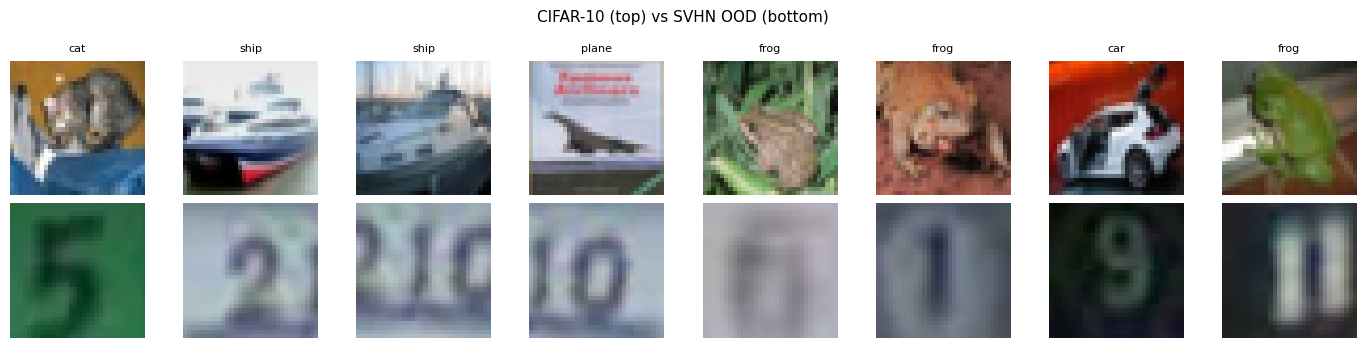

In [57]:
# Visualise a few samples
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
fig, axes = plt.subplots(2, 8, figsize=(14, 3.5))
fig.suptitle("CIFAR-10 (top) vs SVHN OOD (bottom)", fontsize=11)
for i in range(8):
    axes[0, i].imshow(Xte_i[i].permute(1, 2, 0).numpy())
    axes[0, i].set_title(classes[yte[i]], fontsize=8); axes[0, i].axis("off")
    axes[1, i].imshow(Xood_i[i].permute(1, 2, 0).numpy())
    axes[1, i].axis("off")
plt.tight_layout()
plt.show()

## 2. Model Training

In [58]:
def build_cifar_models(arch, d_hidden, K, in_ch=3, img_size=32):
    snn = models.SubjectiveCNN(arch, d_hidden, K, in_channels=in_ch, input_size=img_size)
    mcd = models.MCDropoutCNN(arch, d_hidden, K, p_drop=0.5, in_channels=in_ch, input_size=img_size)
    edl = models.EDLCNN(arch, d_hidden, K, in_channels=in_ch, input_size=img_size)
    return {"snn": snn, "mcd": mcd, "edl": edl}


def train_or_load_cifar(arch, d_hidden, K, Xtr, ytr, Xte, yte,
                        epochs=30, beta_max=2, seed=0, device="cpu"):
    torch.manual_seed(seed)
    exp = "cifar10"
    tp = {"arch": arch, "d_hidden": d_hidden, "epochs": epochs,
          "beta_max": beta_max, "seed": seed, "in_ch": 3}
    heads = build_cifar_models(arch, d_hidden, K)
    loaded = cache.load_models(exp, tp, **heads)

    for name in ["snn", "mcd", "edl"]:
        if name not in loaded:
            print(f"\n[Training {name.upper()} for CIFAR-10]")
            torch.manual_seed(seed)
            heads[name] = build_cifar_models(arch, d_hidden, K)[name]
            models.train_head(
                heads[name], Xtr, ytr, K, epochs=epochs,
                beta_max=beta_max, is_snn=(name=="snn"), is_edl=(name=="edl"),
                device=device, verbose=True, Xte=Xte, yte=yte
            )
    # Save all (including already loaded ones - harmless overwrite)
    to_save = {k: v for k, v in heads.items() if k not in loaded}
    if to_save:
        cache.save_models(exp, tp, **to_save)
    return heads


heads = train_or_load_cifar(
    ARCH, D_HIDDEN, K, Xtr, ytr, Xte, yte,
    epochs=EPOCHS, beta_max=BETA_MAX, seed=SEED, device=DEVICE
)
snn_model = heads["snn"]
mcd_model = heads["mcd"]
edl_model = heads["edl"]
print("\nSNN / MCD / EDL ready.")


[Training SNN for CIFAR-10]


Epoch 1/30: 100%|██████████| 781/781 [00:19<00:00, 40.87it/s]


  ep   1/30 loss=1.4279 tr_acc=0.4706 te_acc=0.4835 kl=20.9 beta=33.29 std(E[p])=0.0048


Epoch 2/30: 100%|██████████| 781/781 [00:19<00:00, 40.30it/s]


  ep   2/30 loss=1.0144 tr_acc=0.6406 te_acc=0.6780 kl=15.6 beta=66.62 std(E[p])=0.0025


...

  ep  28/30 loss=0.5082 tr_acc=0.7886 te_acc=0.7390 lam=1.00


Epoch 29/30: 100%|██████████| 781/781 [00:17<00:00, 43.40it/s]


  ep  29/30 loss=0.4973 tr_acc=0.7902 te_acc=0.7830 lam=1.00


Epoch 30/30: 100%|██████████| 781/781 [00:18<00:00, 42.75it/s]


  ep  30/30 loss=0.4929 tr_acc=0.7946 te_acc=0.7790 lam=1.00
[models] saved → results/models/cifar10_6c1d59419414/

SNN / MCD / EDL ready.


In [ ]:
def build_det_model(arch, d_hidden, K, in_ch=3, img_size=32):
    return models.MCDropoutCNN(arch, d_hidden, K, p_drop=0.0,
                               in_channels=in_ch, input_size=img_size)


def train_or_load_ensemble(arch, d_hidden, K, Xtr, ytr, Xte, yte,
                           n_models=5, epochs=30, device="cpu"):
    ensemble = []
    exp = "deep_ensemble_cifar10"
    for i in range(n_models):
        seed_i = i * 42 + 7
        tp = {"arch": arch, "d_hidden": d_hidden, "epochs": epochs,
              "seed": seed_i, "member": i, "in_ch": 3}
        model = build_det_model(arch, d_hidden, K)
        loaded = cache.load_models(exp, tp, det=model)
        if "det" not in loaded:
            print(f"\n[Training ensemble member {i+1}/{n_models} (seed={seed_i})]")
            torch.manual_seed(seed_i)
            model = build_det_model(arch, d_hidden, K)
            models.train_head(model, Xtr, ytr, K, epochs=epochs,
                              device=device, verbose=True, Xte=Xte, yte=yte)
            cache.save_models(exp, tp, det=model)
        ensemble.append(model)
    return ensemble


ensemble = train_or_load_ensemble(
    ARCH, D_HIDDEN, K, Xtr, ytr, Xte, yte,
    n_models=N_ENSEMBLE, epochs=EPOCHS, device=DEVICE
)
print(f"\nEnsemble ready: {N_ENSEMBLE} members")


[Training ensemble member 1/5 (seed=7)]


Epoch 1/30: 100%|██████████| 781/781 [00:17<00:00, 44.98it/s]


  ep   1/30 loss=1.3953 tr_acc=0.4783 te_acc=0.5620


Epoch 2/30: 100%|██████████| 781/781 [00:17<00:00, 43.53it/s]


  ep   2/30 loss=0.9704 tr_acc=0.6535 te_acc=0.6895


...

  ep  28/30 loss=0.0800 tr_acc=0.9719 te_acc=0.8155


Epoch 29/30: 100%|██████████| 781/781 [00:17<00:00, 44.89it/s]


  ep  29/30 loss=0.0796 tr_acc=0.9727 te_acc=0.8350


Epoch 30/30: 100%|██████████| 781/781 [00:17<00:00, 45.10it/s]


  ep  30/30 loss=0.0725 tr_acc=0.9743 te_acc=0.8275
[models] saved → results/models/deep_ensemble_cifar10_0c50f70c9b11/

Ensemble ready: 5 members


## 3. Uncertainty Decomposition

In [59]:
def _prep(X_img):
    return normalize_cifar(X_img)


def rotate_batch(X, angle_deg):
    """Rotate a batch of images by angle_deg degrees."""
    theta_rad = math.radians(angle_deg)
    c, s = math.cos(theta_rad), math.sin(theta_rad)
    theta = torch.tensor([[c, -s, 0], [s, c, 0]], dtype=torch.float32)
    theta = theta.unsqueeze(0).repeat(X.shape[0], 1, 1)
    grid = F.affine_grid(theta, X.shape, align_corners=False)
    return F.grid_sample(X, grid, align_corners=False, padding_mode="zeros")


# ---- SNN ----
@torch.no_grad()
def snn_uncertainty(model, X_img, Np, Nm, device):
    X = _prep(X_img)
    raw, pb = inference.snn_nested_samples(model, X, Np, Nm, device, desc="SNN")
    H_total, eH, MI, u = aug.bald_split(pb)
    return {"probs": pb.mean(dim=1), "total": H_total,
            "epistemic": MI, "aleatoric": eH, "u_star": u}


# ---- MC Dropout ----
@torch.no_grad()
def mcd_uncertainty(model, X_img, T, device):
    X = _prep(X_img)
    pm, sm = inference.mc_dropout_probs(model, X, T=T, device=device, desc="MCD")
    op = aug.bald_opinion(sm)
    return {"probs": op["probs"], "total": op["H_total"],
            "epistemic": op["MI"], "aleatoric": op["eH"], "u_star": op["u"]}


# ---- EDL ----
@torch.no_grad()
def edl_uncertainty(model, X_img, device):
    X = _prep(X_img)
    pe, ue = inference.edl_opinion(model, X, device)
    H = -(pe.clamp_min(1e-12) * pe.clamp_min(1e-12).log()).sum(-1)
    return {"probs": pe, "total": H, "epistemic": ue,
            "aleatoric": H - ue, "u_star": ue}


# ---- Deep Ensembles ----
@torch.no_grad()
def de_uncertainty(ensemble, X_img, device):
    X = _prep(X_img)
    all_probs = []
    for m in ensemble:
        m.eval().to(device)
        logits = m(X.to(device), sample=False)
        all_probs.append(F.softmax(logits, dim=1).cpu())
    samples = torch.stack(all_probs, dim=1)
    op = aug.bald_opinion(samples)
    return {"probs": op["probs"], "total": op["H_total"],
            "epistemic": op["MI"], "aleatoric": op["eH"], "u_star": op["u"]}


# ---- ICE ----
def generate_clarifications(X_img, n_clarifications=10, seed=42):
    g = torch.Generator().manual_seed(seed)
    versions = [X_img]
    for i in range(n_clarifications - 1):
        angle = (torch.rand(1, generator=g).item() - 0.5) * 20
        X_rot = rotate_batch(X_img, angle)
        tx = (torch.rand(1, generator=g).item() - 0.5) * 0.1
        ty = (torch.rand(1, generator=g).item() - 0.5) * 0.1
        theta = torch.tensor([[1., 0., tx], [0., 1., ty]]).unsqueeze(0).repeat(len(X_img),1,1)
        grid = F.affine_grid(theta, X_rot.shape, align_corners=False)
        X_trans = F.grid_sample(X_rot, grid, align_corners=False, padding_mode="zeros")
        noise_std = 0.02 + torch.rand(1, generator=g).item() * 0.03
        X_aug = (X_trans + torch.randn_like(X_trans) * noise_std).clamp(0, 1)
        versions.append(X_aug)
    return versions


@torch.no_grad()
def ice_uncertainty(model, X_img, n_clarifications, device, seed=42):
    clarifications = generate_clarifications(X_img, n_clarifications, seed)
    model.eval().to(device)
    all_probs = []
    for X_c in clarifications:
        X = _prep(X_c)
        logits = model(X.to(device), sample=False)
        all_probs.append(F.softmax(logits, dim=1).cpu())
    samples = torch.stack(all_probs, dim=1)
    H_total, eH, MI, u = aug.bald_split(samples)
    return {"probs": samples.mean(dim=1), "total": H_total,
            "aleatoric": MI, "epistemic": eH, "u_star": u}


print("All uncertainty methods defined.")

All uncertainty methods defined.


## 4. Compute Uncertainties on Clean Test Set

In [60]:
ice_model = mcd_model

print("Computing uncertainties on clean test set...")
u_snn = snn_uncertainty(snn_model, Xte_i, Np, Nm, DEVICE)
u_mcd = mcd_uncertainty(mcd_model, Xte_i, T_MCD, DEVICE)
u_edl = edl_uncertainty(edl_model, Xte_i, DEVICE)
u_de  = de_uncertainty(ensemble, Xte_i, DEVICE)
u_ice = ice_uncertainty(ice_model, Xte_i, N_CLARIFY, DEVICE)

all_methods = {
    "SNN":              u_snn,
    "MC Dropout":       u_mcd,
    "EDL":              u_edl,
    "Deep Ensembles":   u_de,
    "ICE (Hou et al.)": u_ice,
}
print("Done.")

Computing uncertainties on clean test set...


Done.


## 5. Experiment 1: Mistake Detection

In [61]:
def best_f1_score(scores, labels):
    s, lab = metrics._np(scores), metrics._np(labels).astype(int)
    order = np.argsort(-s)
    s, lab = s[order], lab[order]
    tp_cum = np.cumsum(lab)
    P = lab.sum()
    if P == 0:
        return 0.0
    prec = tp_cum / (np.arange(len(lab)) + 1)
    rec  = tp_cum / P
    f1 = np.where((prec + rec) > 0, 2 * prec * rec / (prec + rec), 0.0)
    return float(f1.max())


def mistake_detection(u_dict, yte):
    preds = u_dict["probs"].argmax(1)
    correct = (preds == yte)
    total_u = metrics._np(u_dict["total"])
    correct_np = metrics._np(correct).astype(int)
    wrong_labels = 1 - correct_np
    auroc = metrics._roc_auc(total_u, wrong_labels)
    f1 = best_f1_score(total_u, wrong_labels)
    ent_correct = total_u[correct_np == 1].mean() if correct_np.sum() > 0 else 0
    ent_wrong   = total_u[correct_np == 0].mean() if (1-correct_np).sum() > 0 else 0
    acc = correct_np.mean()
    return {"AUROC": auroc, "F1": f1 * 100, "Entropy(V)": ent_correct,
            "Entropy(X)": ent_wrong, "Acc": acc}


rows = []
for name, u in all_methods.items():
    r = mistake_detection(u, yte)
    r["Method"] = name
    rows.append(r)

df_mistake = pd.DataFrame(rows)[["Method", "Acc", "AUROC", "F1", "Entropy(V)", "Entropy(X)"]]
print("\n=== Experiment 1: Mistake Detection (CIFAR-10) ===")
display(df_mistake.round(4))


=== Experiment 1: Mistake Detection (CIFAR-10) ===


/tmp/ipykernel_52808/3797410321.py:11: RuntimeWarning: invalid value encountered in divide
  f1 = np.where((prec + rec) > 0, 2 * prec * rec / (prec + rec), 0.0)


,Method,Acc,AUROC,F1,Entropy(V),Entropy(X)
0,SNN,0.8295,0.8681,57.3892,0.0858,0.4602
1,MC Dropout,0.8375,0.8637,55.9424,0.1071,0.5165
2,EDL,0.7815,0.8637,64.9425,1.1227,2.1808
3,Deep Ensembles,0.8865,0.8942,52.3179,0.2640,0.9376
4,ICE (Hou et al.),0.6030,0.7478,66.4474,0.7006,1.0797


## 6. Experiment 2: Ambiguity Detection

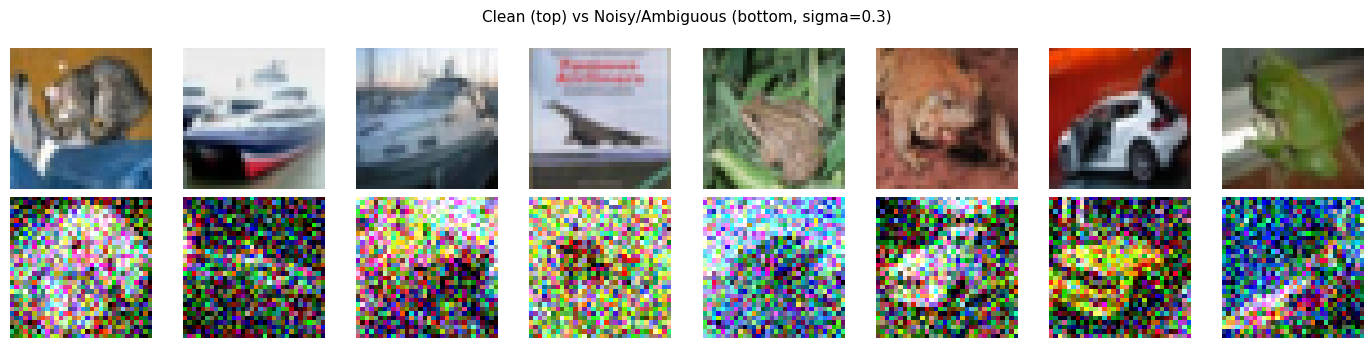

In [62]:
n_half = N_TEST // 2
Xclean = Xte_i[:n_half]
yclean = yte[:n_half]

g_noise = torch.Generator().manual_seed(123)
noise_sigma = 0.3
Xnoisy = (Xte_i[n_half:2*n_half] + noise_sigma * torch.randn(
    n_half, 3, 32, 32, generator=g_noise)).clamp(0, 1)
ynoisy = yte[n_half:2*n_half]

Xmixed = torch.cat([Xclean, Xnoisy], dim=0)
ymixed = torch.cat([yclean, ynoisy], dim=0)
ambig_labels = torch.cat([torch.zeros(n_half), torch.ones(n_half)])

fig, axes = plt.subplots(2, 8, figsize=(14, 3.5))
fig.suptitle(f"Clean (top) vs Noisy/Ambiguous (bottom, sigma={noise_sigma})", fontsize=11)
for i in range(8):
    axes[0, i].imshow(Xclean[i].permute(1,2,0).numpy()); axes[0, i].axis("off")
    axes[1, i].imshow(Xnoisy[i].permute(1,2,0).numpy()); axes[1, i].axis("off")
plt.tight_layout()
plt.show()

In [63]:
print("Computing uncertainties on mixed (clean + noisy) test set...")
u_mix = {}
u_mix["SNN"]              = snn_uncertainty(snn_model, Xmixed, Np, Nm, DEVICE)
u_mix["MC Dropout"]       = mcd_uncertainty(mcd_model, Xmixed, T_MCD, DEVICE)
u_mix["EDL"]              = edl_uncertainty(edl_model, Xmixed, DEVICE)
u_mix["Deep Ensembles"]   = de_uncertainty(ensemble, Xmixed, DEVICE)
u_mix["ICE (Hou et al.)"] = ice_uncertainty(ice_model, Xmixed, N_CLARIFY, DEVICE)


def ambiguity_detection(u_dict, ambig_labels):
    alea = metrics._np(u_dict["aleatoric"])
    labels = metrics._np(ambig_labels).astype(int)
    auroc = metrics._roc_auc(alea, labels)
    f1 = best_f1_score(alea, labels)
    avg_clean = alea[labels == 0].mean()
    avg_noisy = alea[labels == 1].mean()
    return {"AUROC": auroc, "F1": f1 * 100,
            "Avg AU(clean)": avg_clean, "Avg AU(noisy)": avg_noisy}


rows2 = []
for name, u in u_mix.items():
    r = ambiguity_detection(u, ambig_labels)
    r["Method"] = name
    rows2.append(r)

df_ambig = pd.DataFrame(rows2)[["Method", "AUROC", "F1", "Avg AU(clean)", "Avg AU(noisy)"]]
print(f"\n=== Experiment 2: Ambiguity Detection (CIFAR-10, sigma={noise_sigma}) ===")
display(df_ambig.round(4))

Computing uncertainties on mixed (clean + noisy) test set...



=== Experiment 2: Ambiguity Detection (CIFAR-10, sigma=0.3) ===


/tmp/ipykernel_52808/3797410321.py:11: RuntimeWarning: invalid value encountered in divide
  f1 = np.where((prec + rec) > 0, 2 * prec * rec / (prec + rec), 0.0)


,Method,AUROC,F1,Avg AU(clean),Avg AU(noisy)
0,SNN,0.7846,77.9461,0.1623,0.4100
1,MC Dropout,0.8451,80.1049,0.1555,0.5969
2,EDL,0.6536,73.5148,0.8623,1.1737
3,Deep Ensembles,0.8629,82.5485,0.1565,0.4415
4,ICE (Hou et al.),0.6773,70.2746,0.5453,0.7178


## 7. Experiment 3: Monotonicity Check


=== Experiment 3: Monotonicity Check (CIFAR-10) ===


,Method,Aleatoric (ambiguous),Aleatoric (clarified),Drop ratio
0,SNN,0.4458,0.1653,0.6291
1,MC Dropout,0.5824,0.1507,0.7412
2,Deep Ensembles,0.4395,0.1605,0.6347
3,ICE (Hou et al.),0.7190,0.5455,0.2414


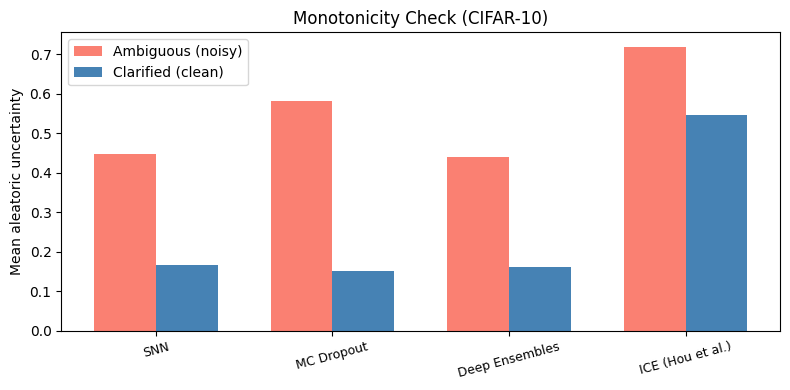

In [64]:
n_mono = min(500, n_half)
X_original   = Xte_i[:n_mono]
X_ambiguous  = (X_original + noise_sigma * torch.randn_like(X_original)).clamp(0, 1)
X_clarified  = X_original

methods_mono = {
    "SNN":              lambda Xi: snn_uncertainty(snn_model, Xi, Np, Nm, DEVICE),
    "MC Dropout":       lambda Xi: mcd_uncertainty(mcd_model, Xi, T_MCD, DEVICE),
    "Deep Ensembles":   lambda Xi: de_uncertainty(ensemble, Xi, DEVICE),
    "ICE (Hou et al.)": lambda Xi: ice_uncertainty(ice_model, Xi, N_CLARIFY, DEVICE),
}

mono_rows = []
for name, fn in methods_mono.items():
    u_ambig  = fn(X_ambiguous)
    u_clarif = fn(X_clarified)
    alea_ambig = metrics._np(u_ambig["aleatoric"]).mean()
    alea_clari = metrics._np(u_clarif["aleatoric"]).mean()
    mono_rows.append({
        "Method": name,
        "Aleatoric (ambiguous)": alea_ambig,
        "Aleatoric (clarified)": alea_clari,
        "Drop ratio": (alea_ambig - alea_clari) / max(alea_ambig, 1e-10),
    })

df_mono = pd.DataFrame(mono_rows)
print("\n=== Experiment 3: Monotonicity Check (CIFAR-10) ===")
display(df_mono.round(4))

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(df_mono))
w = 0.35
ax.bar(x - w/2, df_mono["Aleatoric (ambiguous)"], w, label="Ambiguous (noisy)", color="salmon")
ax.bar(x + w/2, df_mono["Aleatoric (clarified)"], w, label="Clarified (clean)", color="steelblue")
ax.set_xticks(x)
ax.set_xticklabels(df_mono["Method"], fontsize=9, rotation=15)
ax.set_ylabel("Mean aleatoric uncertainty")
ax.set_title("Monotonicity Check (CIFAR-10)")
ax.legend()
plt.tight_layout()
os.makedirs("results", exist_ok=True)
plt.savefig("results/cifar10_monotonicity.png", dpi=140)
plt.show()

## 8. Experiment 4: OOD Detection (CIFAR-10 vs SVHN)

In [65]:
print("Computing uncertainties on OOD (SVHN)...")
u_ood = {}
u_ood["SNN"]              = snn_uncertainty(snn_model, Xood_i, Np, Nm, DEVICE)
u_ood["MC Dropout"]       = mcd_uncertainty(mcd_model, Xood_i, T_MCD, DEVICE)
u_ood["EDL"]              = edl_uncertainty(edl_model, Xood_i, DEVICE)
u_ood["Deep Ensembles"]   = de_uncertainty(ensemble, Xood_i, DEVICE)
u_ood["ICE (Hou et al.)"] = ice_uncertainty(ice_model, Xood_i, N_CLARIFY, DEVICE)

rows_ood = []
for name in all_methods:
    u_id_dict = all_methods[name]
    u_ood_dict = u_ood[name]
    om_total = metrics.ood_metrics(metrics._np(u_id_dict["total"]),   metrics._np(u_ood_dict["total"]))
    om_epi   = metrics.ood_metrics(metrics._np(u_id_dict["epistemic"]), metrics._np(u_ood_dict["epistemic"]))
    om_alea  = metrics.ood_metrics(metrics._np(u_id_dict["aleatoric"]), metrics._np(u_ood_dict["aleatoric"]))
    rows_ood.append({
        "Method": name,
        "AUROC (total)": om_total["auroc"],
        "AUROC (epistemic)": om_epi["auroc"],
        "AUROC (aleatoric)": om_alea["auroc"],
        "FPR@95 (total)": om_total["fpr95"],
    })

df_ood = pd.DataFrame(rows_ood)
print("\n=== Experiment 4: OOD Detection (CIFAR-10 vs SVHN) ===")
display(df_ood.round(4))

Computing uncertainties on OOD (SVHN)...



=== Experiment 4: OOD Detection (CIFAR-10 vs SVHN) ===


,Method,AUROC (total),AUROC (epistemic),AUROC (aleatoric),FPR@95 (total)
0,SNN,0.8089,0.8488,0.8085,0.5570
1,MC Dropout,0.7769,0.8215,0.7692,0.5280
2,EDL,0.7883,0.7941,0.6465,0.5550
3,Deep Ensembles,0.8944,0.8457,0.9031,0.3545
4,ICE (Hou et al.),0.4737,0.5130,0.4689,0.8710


## 9. Rotation Sweep

In [66]:
n_sweep = min(500, N_TEST)
Xsweep_i = Xte_i[:n_sweep]
ysweep   = yte[:n_sweep]
angles   = list(range(0, 181, 15))

sweep_data = {name: {"angle": [], "acc": [], "total": [], "epi": [], "alea": [], "u_star": []}
              for name in ["SNN", "MC Dropout", "Deep Ensembles", "ICE (Hou et al.)"]}

print(f"Rotation sweep ({n_sweep} images, {len(angles)} angles)...")
for ang in angles:
    Xr = rotate_batch(Xsweep_i, ang)
    yr = ysweep

    for name, fn in [
        ("SNN",              lambda Xi: snn_uncertainty(snn_model, Xi, Np, Nm, DEVICE)),
        ("MC Dropout",       lambda Xi: mcd_uncertainty(mcd_model, Xi, T_MCD, DEVICE)),
        ("Deep Ensembles",   lambda Xi: de_uncertainty(ensemble, Xi, DEVICE)),
        ("ICE (Hou et al.)", lambda Xi: ice_uncertainty(ice_model, Xi, N_CLARIFY, DEVICE)),
    ]:
        u = fn(Xr)
        acc = metrics.accuracy(u["probs"], yr)
        sweep_data[name]["angle"].append(ang)
        sweep_data[name]["acc"].append(acc)
        sweep_data[name]["total"].append(metrics._np(u["total"]).mean())
        sweep_data[name]["epi"].append(metrics._np(u["epistemic"]).mean())
        sweep_data[name]["alea"].append(metrics._np(u["aleatoric"]).mean())
        sweep_data[name]["u_star"].append(metrics._np(u["u_star"]).mean())

    print(f"  {ang:3d} deg done")

print("Sweep complete.")

Rotation sweep (500 images, 13 angles)...


    0 deg done


   15 deg done


   30 deg done


   45 deg done


...

  120 deg done


  135 deg done


  150 deg done


  165 deg done


  180 deg done
Sweep complete.


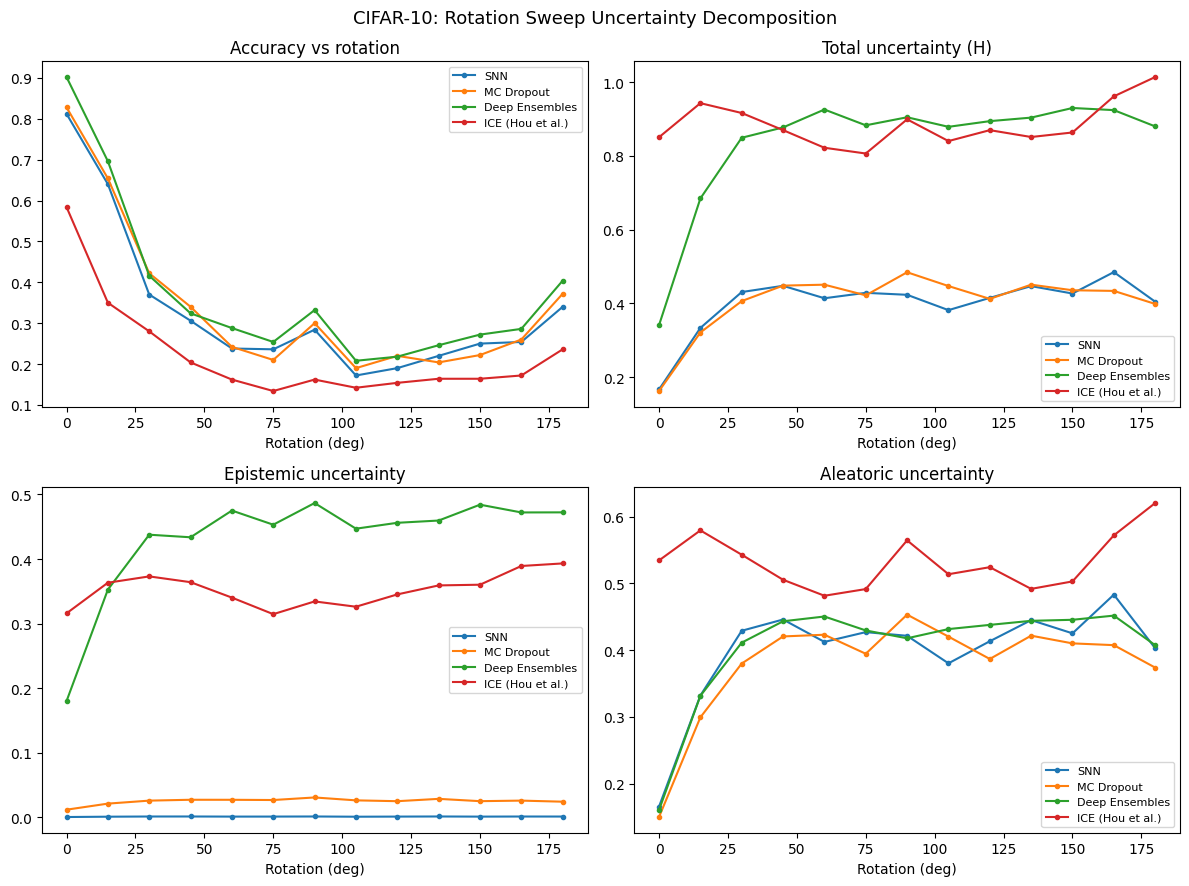

In [67]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
colors = {"SNN": "tab:blue", "MC Dropout": "tab:orange",
          "Deep Ensembles": "tab:green", "ICE (Hou et al.)": "tab:red"}

for ax, key, title in [
    (axes[0,0], "acc",   "Accuracy vs rotation"),
    (axes[0,1], "total", "Total uncertainty (H)"),
    (axes[1,0], "epi",   "Epistemic uncertainty"),
    (axes[1,1], "alea",  "Aleatoric uncertainty"),
]:
    for name, sd in sweep_data.items():
        ax.plot(sd["angle"], sd[key], "-o", ms=3, label=name, color=colors[name])
    ax.set_title(title); ax.set_xlabel("Rotation (deg)"); ax.legend(fontsize=8)

fig.suptitle("CIFAR-10: Rotation Sweep Uncertainty Decomposition", fontsize=13)
fig.tight_layout()
plt.savefig("results/cifar10_rotation_sweep.png", dpi=140)
plt.show()

## 10. Summary

In [68]:
summary_rows = []
for name in all_methods:
    md = df_mistake[df_mistake["Method"] == name].iloc[0]
    ad = df_ambig[df_ambig["Method"] == name].iloc[0]
    od = df_ood[df_ood["Method"] == name].iloc[0]
    summary_rows.append({
        "Method": name,
        "Acc": md["Acc"],
        "Mistake Det. AUROC": md["AUROC"],
        "Ambig Det. AUROC": ad["AUROC"],
        "OOD AUROC (total)": od["AUROC (total)"],
        "OOD AUROC (epi)": od["AUROC (epistemic)"],
    })

df_summary = pd.DataFrame(summary_rows)
print("=" * 70)
print("CIFAR-10: SNN vs ICE Comparison")
print("=" * 70)
display(df_summary.round(4))

CIFAR-10: SNN vs ICE Comparison


,Method,Acc,Mistake Det. AUROC,Ambig Det. AUROC,OOD AUROC (total),OOD AUROC (epi)
0,SNN,0.8295,0.8681,0.7846,0.8089,0.8488
1,MC Dropout,0.8375,0.8637,0.8451,0.7769,0.8215
2,EDL,0.7815,0.8637,0.6536,0.7883,0.7941
3,Deep Ensembles,0.8865,0.8942,0.8629,0.8944,0.8457
4,ICE (Hou et al.),0.6030,0.7478,0.6773,0.4737,0.5130


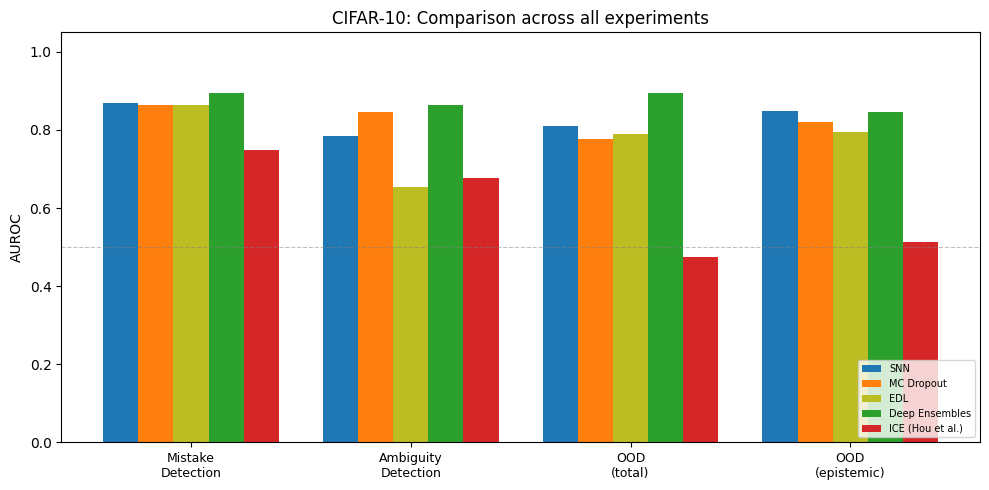

In [69]:
metric_cols = ["Mistake Det. AUROC", "Ambig Det. AUROC",
               "OOD AUROC (total)", "OOD AUROC (epi)"]
short_labels = ["Mistake\nDetection", "Ambiguity\nDetection",
                "OOD\n(total)", "OOD\n(epistemic)"]

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(metric_cols))
n_methods = len(df_summary)
w = 0.8 / n_methods
method_colors = ["tab:blue", "tab:orange", "tab:olive", "tab:green", "tab:red"]

for i, (_, row) in enumerate(df_summary.iterrows()):
    vals = [row[c] for c in metric_cols]
    ax.bar(x + i * w - 0.4 + w/2, vals, w, label=row["Method"],
           color=method_colors[i % len(method_colors)])

ax.set_xticks(x)
ax.set_xticklabels(short_labels, fontsize=9)
ax.set_ylabel("AUROC")
ax.set_title("CIFAR-10: Comparison across all experiments")
ax.legend(fontsize=7, loc="lower right")
ax.set_ylim(0, 1.05)
ax.axhline(0.5, color="gray", ls="--", lw=0.8, alpha=0.5)
plt.tight_layout()
plt.savefig("results/cifar10_summary.png", dpi=140)
plt.show()

In [70]:
results = {
    "mistake_detection": df_mistake.to_dict(orient="records"),
    "ambiguity_detection": df_ambig.to_dict(orient="records"),
    "monotonicity_check": df_mono.to_dict(orient="records"),
    "ood_detection": df_ood.to_dict(orient="records"),
    "summary": df_summary.to_dict(orient="records"),
    "rotation_sweep": {name: sd for name, sd in sweep_data.items()},
    "config": {
        "dataset": "CIFAR-10", "ood_dataset": "SVHN",
        "arch": ARCH, "epochs": EPOCHS, "d_hidden": D_HIDDEN,
        "Np": Np, "Nm": Nm, "T_mcd": T_MCD,
        "n_ensemble": N_ENSEMBLE, "n_clarify": N_CLARIFY,
        "n_test": N_TEST, "noise_sigma": noise_sigma,
    },
}
os.makedirs("results", exist_ok=True)
with open("results/comparison_cifar10.json", "w") as f:
    json.dump(results, f, indent=2, default=float)
print("Results saved to results/comparison_cifar10.json")

Results saved to results/comparison_cifar10.json
